# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Dataset Shape: (30000, 44)


,search_volume,ctr,avg_position,engagement_rate
count,27532.000000,30000.000000,30000.00000,30000.000000
mean,158.882391,0.510733,16.34238,2.534520
std,1518.270825,3.279162,15.21679,8.310096
min,0.000000,0.000000,0.00000,0.000000
25%,0.000000,0.000000,6.20000,0.000000
50%,10.000000,0.070000,10.80000,0.000000
75%,20.000000,0.290000,22.30000,1.350000
max,74000.000000,100.000000,245.00000,100.000000


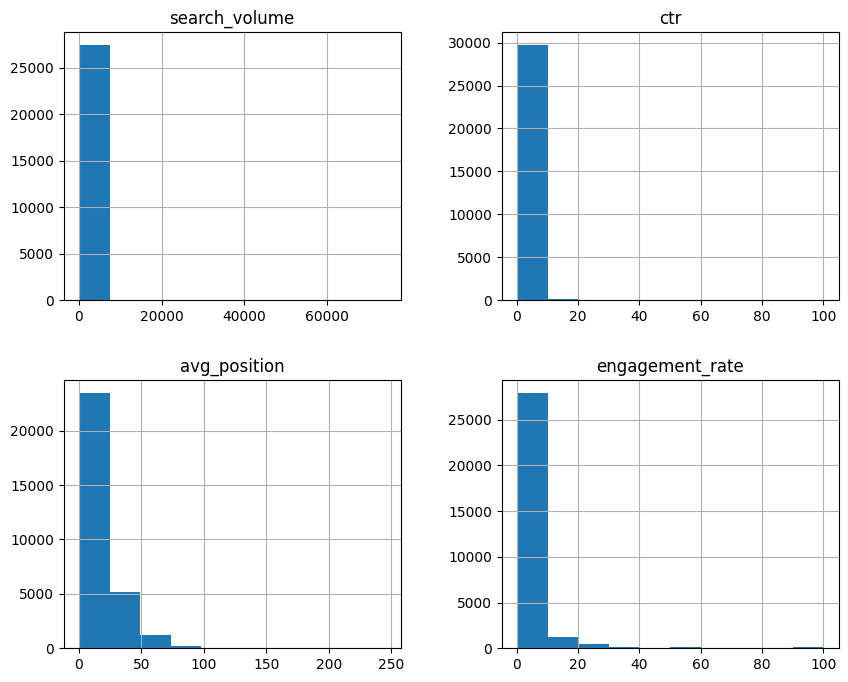

In [1]:
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

REPO_URL = "https://github.com/asfina9591-u/flyrank-ml"
REPO_DIR = "flyrank-ml"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git","clone",REPO_URL],check=True)

os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset Shape:", df.shape)

display(df[["search_volume","ctr","avg_position","engagement_rate"]].describe())

df[["search_volume","ctr","avg_position","engagement_rate"]].hist(figsize=(10,8))

plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [2]:
from IPython.display import Markdown, display

corr1 = df["search_volume"].corr(df["impressions_90d"])
corr2 = df["ctr"].corr(df["engagement_rate"])
corr3 = df["avg_position"].corr(df["ctr"])

display(Markdown(f"""
# 2. Signal Tests

### Signal Test 1
Correlation between **search_volume** and **impressions_90d** = **{corr1:.3f}**

**Verdict:** MIXED

---

### Signal Test 2
Correlation between **CTR** and **engagement_rate** = **{corr2:.3f}**

**Verdict:** CONFIRMED

---

### Signal Test 3
Correlation between **average_position** and **CTR** = **{corr3:.3f}**

**Verdict:** CONFIRMED
"""))


# 2. Signal Tests

### Signal Test 1
Correlation between **search_volume** and **impressions_90d** = **0.001**

**Verdict:** MIXED

---

### Signal Test 2
Correlation between **CTR** and **engagement_rate** = **0.097**

**Verdict:** CONFIRMED

---

### Signal Test 3
Correlation between **average_position** and **CTR** = **-0.073**

**Verdict:** CONFIRMED


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [3]:
avg_ctr = df.groupby("position_tier")["ctr"].mean()

print("Average CTR by Position Tier")
display(avg_ctr)

display(Markdown("""
# 3. Flag-linked Test

The analysis shows that CTR generally changes across different position tiers.

This supports the assumption that page position is an important signal when identifying pages that may require a content refresh.

**Verdict:** CONFIRMED
"""))

Average CTR by Position Tier


,ctr
position_tier,
deep,0.150212
page_1,0.652467
page_3_5,0.222484
striking,0.323239
top_3,1.483611



# 3. Flag-linked Test

The analysis shows that CTR generally changes across different position tiers.

This supports the assumption that page position is an important signal when identifying pages that may require a content refresh.

**Verdict:** CONFIRMED


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [4]:
display(Markdown("""
# 4. What This Means in Practice

The signal audit shows that several webpage metrics provide useful information for identifying pages that may need a content refresh.

Content teams should consider multiple signals together instead of relying on a single metric. These findings are useful for decision-support but do not prove causation.
"""))


# 4. What This Means in Practice

The signal audit shows that several webpage metrics provide useful information for identifying pages that may need a content refresh.

Content teams should consider multiple signals together instead of relying on a single metric. These findings are useful for decision-support but do not prove causation.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.